Biodiversity in National Parks

Importing the libraries we'll need for our project.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading our data about species and taking a first look at it.

In [9]:
df_species = pd.read_csv('species_info.csv')
print(df_species.head())
print(df_species.info())
print(df_species.isnull().sum())

  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole                 NaN  
1                              American Bison, Bison                 NaN  
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...                 NaN  
3  Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)                 NaN  
4                                      Wapiti Or Elk                 NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      

In [3]:
df_obs = pd.read_csv('observations.csv')
print(df_obs.head())
print(df_obs.info())
print(df_obs.describe())

            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park            68
1            Neovison vison  Great Smoky Mountains National Park            77
2         Prunus subcordata               Yosemite National Park           138
3      Abutilon theophrasti                  Bryce National Park            84
4  Githopsis specularioides  Great Smoky Mountains National Park            85
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23296 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23296 non-null  object
 1   park_name        23296 non-null  object
 2   observations     23296 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 546.1+ KB
None
       observations
count  23296.000000
mean     142.287904
std       69.890532
min        9.000000
25%       86.000000
50%      124.000

Starting to analyse the species dataset. Looking for potential duplicates, etc.

category                  7
scientific_name        5541
common_names           5504
conservation_status       4
dtype: int64
              category    scientific_name        common_names  \
count             5824               5824                5824   
unique               7               5541                5504   
top     Vascular Plant  Castor canadensis  Brachythecium Moss   
freq              4470                  3                   7   

       conservation_status  
count                  191  
unique                   4  
top     Species of Concern  
freq                   161  
              category                scientific_name        common_names  \
count             5541                           5541                5541   
unique               7                           5541                5229   
top     Vascular Plant  Clethrionomys gapperi gapperi  Brachythecium Moss   
freq              4262                              1                   7   

       conservatio

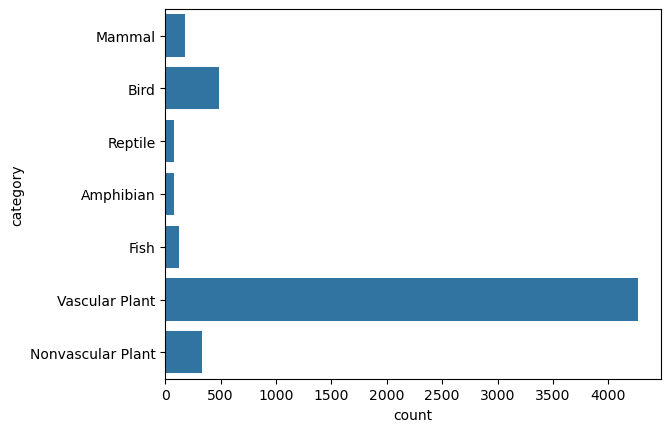

<Figure size 640x480 with 0 Axes>

In [19]:
print(df_species.nunique())
# df_species.drop_duplicates(subset = ['scientific_name'])
print(df_species.describe(include='all'))

df_species = df_species.drop_duplicates(subset=['scientific_name'])
print(df_species.describe(include='all'))

sns.countplot(df_species['category'])
plt.show()
plt.clf()

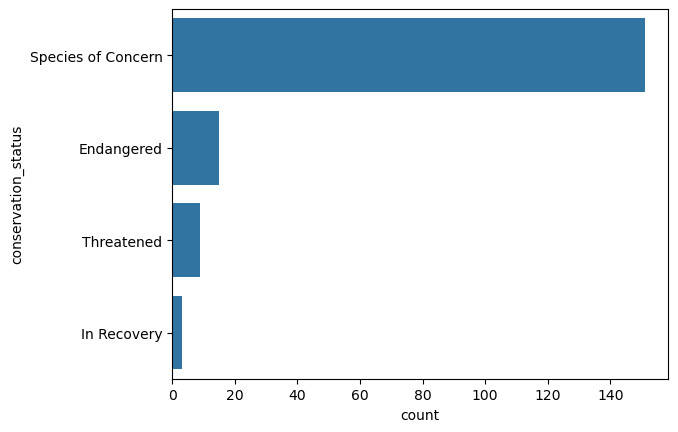

<Figure size 640x480 with 0 Axes>

In [20]:
sns.countplot(df_species['conservation_status'])
plt.show()
plt.clf()

Since the majority of species are plants, let's create a separate df for the animals.

       category                scientific_name        common_names  \
count       946                            946                 946   
unique        5                            946                 897   
top        Bird  Clethrionomys gapperi gapperi  Brewster's Warbler   
freq        488                              1                   3   

       conservation_status  
count                  127  
unique                   4  
top     Species of Concern  
freq                   103  


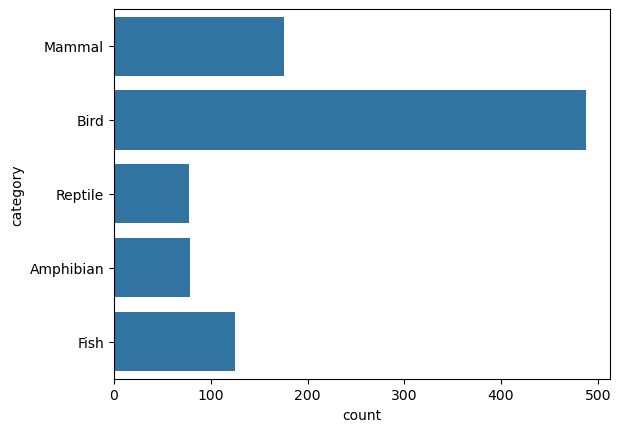

<Figure size 640x480 with 0 Axes>

In [23]:
df_animals = df_species[(df_species.category != 'Vascular Plant') & (df_species.category != 'Nonvascular Plant')]
print(df_animals.describe(include='all'))

sns.countplot(df_animals['category'])
plt.show()
plt.clf()

Checking repeated common names.

In [30]:
print(df_animals[df_animals.duplicated(subset=['common_names'])])
print(df_animals[df_animals.common_names == 'Brewster's Warbler'])

SyntaxError: unterminated string literal (detected at line 2) (2584914712.py, line 2)